In [37]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

<llm-snippet-file>compounds-tp.ipynb</llm-snippet-file>

In [7]:
def read_compounds(path):
    """Read in a compounds file and return a pandas dataframe"""
    df = pd.read_csv(path, sep="\t", header=None,
                     names=["compound", "constituents", "e_interfixation", "frequency"])
    return df

In [39]:
def tp(n, e):
    """Test for productivity"""
    return e <= n / np.log(n) and e < n / 2

def sample_weighted(df, sample_size=100, reps=1000):
    """Repeatedly sample from the dataframe to see if it's productive"""
    samples = []
    for _ in range(reps):
        sample = df.sample(n=sample_size, replace=False, weights=df["frequency"])
        e_interfixation_count = sample["e_interfixation"].sum()
        samples.append(tp(sample_size, sample_size - e_interfixation_count))
    return sum(samples) / len(samples)


In [32]:
compounds = read_compounds("data/compounds.txt")
compounds

,compound,constituents,e_interfixation,frequency
0,Eisenbahn,Eisen+Bahn,False,2066
1,Flugzeug,Flug+Zeug,False,2037
2,Bahnhof,Bahn+Hof,False,1123
3,Geburtstag,Geburt+s+Tag,False,1019
4,Feuerwehr,Feuer+Wehr,False,821
...,...,...,...,...
1356,Handgriff,Hand+Griff,False,1
1357,Brachvogel,Brache+Vogel,True,1
1358,Regentonne,Regen+Tonne,False,1
1359,Butterblume,Butter+Blume,False,1


In [44]:
percents = []
sizes = range(5, 500, 1)
for size in sizes:
    percents.append(sample_weighted(compounds, size))

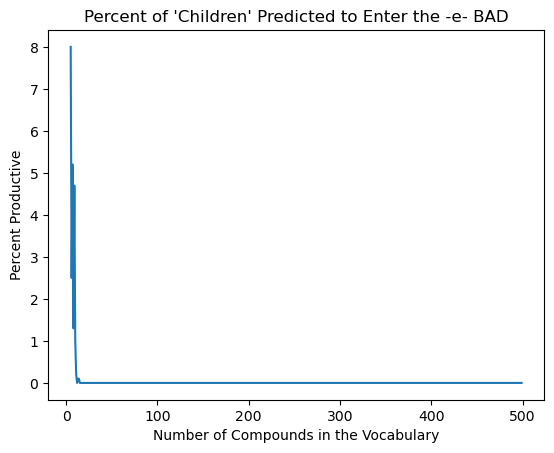

In [52]:
plt.plot(list(sizes), [p * 100 for p in percents])
plt.title("Percent of 'Children' Predicted to Enter the -e- BAD")
plt.xlabel("Number of Compounds in the Vocabulary")
plt.ylabel("Percent Productive")
plt.savefig("data/tp-compounds.png")